In [2]:
print("Hello World")

Hello World


In [4]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame for features (X) and target (y)
X = housing.data
y = housing.target

print("Features (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Target (y) head:


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

###

## 2. Data Preparation: Splitting into Training and Testing Sets

Before training a model, it's crucial to split our data into training and testing sets. The model learns from the training data, and its performance is evaluated on the unseen testing data. This helps us understand how well the model generalizes to new, real-world data.


In [25]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (16512, 8)
Shape of X_test: (4128, 8)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


###

## 3. Build and Train a Regression Model: Linear Regression

Linear Regression is one of the simplest and most fundamental regression algorithms. It models the relationship between a dependent variable (target) and one or more independent variables (features) by fitting a linear equation to the observed data.

In [21]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Linear Regression model trained successfully!
Model coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Model intercept: -37.02327770606397


#### 
## 4. Evaluate the Model

After training, we need to evaluate how well our model performs on unseen data (the test set). Common metrics for regression include Mean Squared Error (MSE) and R-squared.

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}")

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 0.56
Root Mean Squared Error (RMSE): 0.75
R-squared (R2): 0.58


#### 
## 5. Visualize Predictions vs. Actual Values
Visualizing the predictions against the actual values can give a good qualitative understanding of the model's performance.

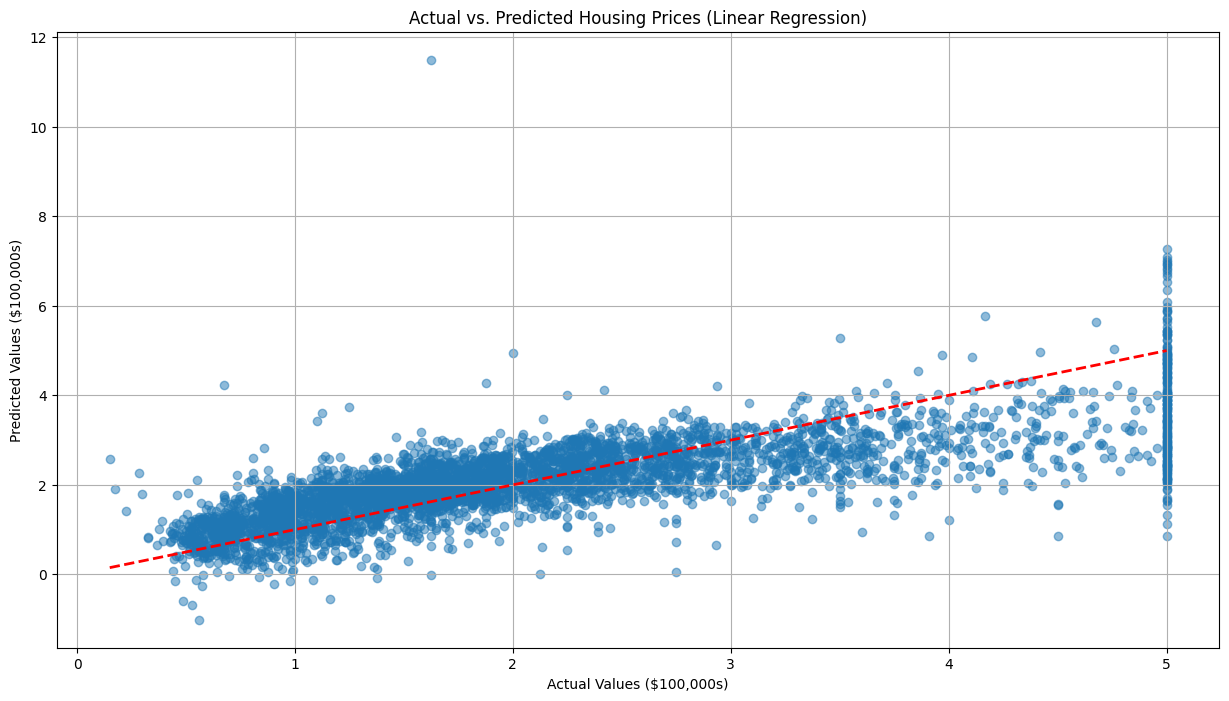

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.scatter(y_test, y_pred, alpha=.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Values ($100,000s)")
plt.ylabel("Predicted Values ($100,000s)")
plt.title("Actual vs. Predicted Housing Prices (Linear Regression)")
plt.grid(True)
plt.show()